# Breast Cancer Classification (Final Human Version)
We load, clean, train SVM, tune hyperparameters, and compare models.

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
import matplotlib.pyplot as plt


In [17]:
cols = [
    "id", "thickness", "size", "shape",
    "adhesion", "epithelial",
    "nuclei", "chromatin",
    "nucleoli", "mitosis", "class_label"
]
df = pd.read_csv("breast-cancer-wisconsin.data", names=cols)
df.head()

,id,thickness,size,shape,adhesion,epithelial,nuclei,chromatin,nucleoli,mitosis,class_label
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [18]:
df.replace("?", np.nan, inplace=True)
df.dropna(inplace=True)
df = df.astype(float)
df.drop("id", axis=1, inplace=True)
df["class_label"] = df["class_label"].map({2: 0, 4: 1})
df.head()


,thickness,size,shape,adhesion,epithelial,nuclei,chromatin,nucleoli,mitosis,class_label
0,5.0,1.0,1.0,1.0,2.0,1.0,3.0,1.0,1.0,0
1,5.0,4.0,4.0,5.0,7.0,10.0,3.0,2.0,1.0,0
2,3.0,1.0,1.0,1.0,2.0,2.0,3.0,1.0,1.0,0
3,6.0,8.0,8.0,1.0,3.0,4.0,3.0,7.0,1.0,0
4,4.0,1.0,1.0,3.0,2.0,1.0,3.0,1.0,1.0,0


In [19]:
# Split data into features and labels
X = df.drop("class_label", axis=1) 
y = df["class_label"]                

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel='rbf', C=10))
])

svm_scores = cross_val_score(svm_model, X_train, y_train, cv=5, scoring='balanced_accuracy')
print("SVM Accuracy:", svm_scores.mean())


SVM Accuracy: 0.9490904943833037


Test Accuracy: 0.9566947565543071
[[85  4]
 [ 2 46]]


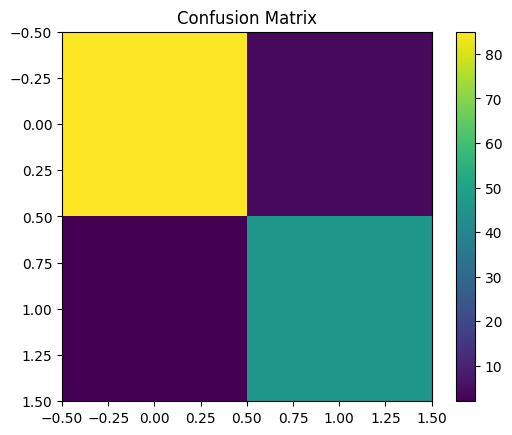

In [21]:
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)

print("Test Accuracy:", balanced_accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()


In [22]:
log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000))
])

log_scores = cross_val_score(log_model, X_train, y_train, cv=5, scoring='balanced_accuracy')
print("Logistic:", log_scores.mean())

Logistic: 0.9653684590674952


In [23]:
poly_model = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2)),
    ("logreg", LogisticRegression(max_iter=2000))
])

poly_scores = cross_val_score(poly_model, X_train, y_train, cv=5, scoring='balanced_accuracy')
print("Logistic + Polynomial:", poly_scores.mean())


Logistic + Polynomial: 0.9585790043907169


In [24]:
# Hyperparameter tuning
kernels = ['linear','rbf','poly']
C_values = [0.1,1,10,100]
results=[]
for k in kernels:
    for c in C_values:
        model = Pipeline([('scaler',StandardScaler()),('svm',SVC(kernel=k,C=c))])
        score = cross_val_score(model,X_train,y_train,cv=5,scoring='balanced_accuracy').mean()
        print(k,c,score)
        results.append((k,c,score))
best = max(results, key=lambda x:x[2])
print('Best:', best)


linear 0.1 0.966406264849556
linear 1 0.9626190340423104
linear 10 0.965183136606413
linear 100 0.965183136606413
rbf 0.1 0.9674440706316169
rbf 1 0.9662209423884738
rbf 10 0.9490904943833037
rbf 100 0.9399222596035051
poly 0.1 0.8964323050312674
poly 1 0.9355857140141796
poly 10 0.9511223888540419
poly 100 0.9469645131246317
Best: ('rbf', 0.1, np.float64(0.9674440706316169))
